## Setup and training

### Specify model and training parameters

In [29]:
import numpy as np
import matplotlib.pyplot as plt

K_MAX = 9

base_hidden_dim = 2*64
base_dropout = 0.1
base_norm = "batch"

lr = 1e-3
batch_size = 128
max_epochs = 500
patience = 100


depths = np.arange(0, K_MAX)

### Load and process data

In [30]:
import torch

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
DATA_ROOT = PROJECT_ROOT / "training_data"

sys.path.append(str(PROJECT_ROOT))

print("PROJECT_ROOT =", PROJECT_ROOT)
print("DATA_ROOT    =", DATA_ROOT)

PROJECT_ROOT = /home/fmoller/Projects/LearningOrganoids/GraphNN
DATA_ROOT    = /home/fmoller/Projects/LearningOrganoids/GraphNN/training_data


In [31]:
from src.data.io import load_graph_dataset_from_dir
from src.data.metadata import load_aux_metadata_for_dir, attach_metadata_to_graphs, load_marker_names_from_dir

# Load all organoids
data_dir = PROJECT_ROOT / "training_data" / "full_set"
graphs = load_graph_dataset_from_dir(str(data_dir))
print(f"Loaded {len(graphs)} organoids.")

meta = load_aux_metadata_for_dir(str(data_dir))
attached = attach_metadata_to_graphs(
    graphs,
    meta,
    exclude_keys=["graph_path", "seg_path"],
)
print(f"Attached metadata to {attached}/{len(graphs)} graphs.")

marker_names = load_marker_names_from_dir(str(data_dir))

Loaded 1224 graphs; skipped 0.
Loaded 1224 organoids.
Attached metadata to 1224/1224 graphs.


In [32]:
from src.data.metadata import ensure_metadata_keys

graphs = ensure_metadata_keys(
    graphs,
    required_keys=["complexity", "dataset", "timepoint", "num_nodes"],
    defaults={
        "complexity": np.nan,
        "dataset": None,
        "timepoint": None,
        "num_nodes": np.nan,
    },
    inplace=False,
)


complexities = np.array([
    np.nan if getattr(g, "meta", {}).get("complexity", None) is None
    else float(getattr(g, "meta", {}).get("complexity"))
    for g in graphs
], dtype=float)

mask_keep = (~np.isfinite(complexities)) | (complexities >= 1.0)

graphs = [g for g, keep in zip(graphs, mask_keep) if keep]

print(f"After complexity filter: {len(graphs)} organoids.")

After complexity filter: 881 organoids.


In [33]:
from src.data.preprocessing import subtract_organoid_mean_curvature

graphs = subtract_organoid_mean_curvature(graphs, inplace=False)

In [34]:
from src.data.metadata import strip_graph_metadata
from src.data.splits import standardize_graph_targets, train_val_split_graphs

graphs = strip_graph_metadata(graphs, inplace=False)


# Split dataset by organoid
g_train, g_val = train_val_split_graphs(graphs, val_frac=0.2, seed=None)
print(f"Split -> train: {len(g_train)} | val: {len(g_val)}")

center, scale = standardize_graph_targets(g_train, g_val, robust=True)

Split -> train: 705 | val: 176


In [35]:
from src.data.ring_features import attach_precomputed_ring_features

g_train = attach_precomputed_ring_features(
    g_train,
    k_hops=K_MAX,
    inplace=False,
)

g_val = attach_precomputed_ring_features(
    g_val,
    k_hops=K_MAX,
    inplace=False,
)

In [36]:
from src.training.loop import TrainConfig, train

cfg = TrainConfig(
    loss_name="gaussian",
    lr=lr,
    batch_size=batch_size,
    max_epochs=max_epochs,
    patience=patience,
    num_workers=4,
)

device = cfg.device if "cfg" in globals() else ("cuda" if torch.cuda.is_available() else "cpu")

In [37]:
import copy
import torch

from src.inference.predict import predict_targets


def predict_means_per_graph(graphs, model, device=None, batch_size=32, num_workers=0, pin_memory=True):
    """
    Predict nodewise means with the existing predict_targets(...) helper,
    then split the concatenated output back into one array per graph.
    """
    y_true, mu_pred, X = predict_targets(
        graphs,
        model,
        device=device,
        batch_size=batch_size,
        num_workers=num_workers,
        pin_memory=pin_memory,
        return_log_var=False,
        center_only=False,
    )

    lengths = [int(g.y.numel()) for g in graphs]
    if np.sum(lengths) != len(mu_pred):
        raise RuntimeError(
            f"Prediction length mismatch: sum(lengths)={np.sum(lengths)} "
            f"but got len(mu_pred)={len(mu_pred)}"
        )

    mu_per_graph = []
    start = 0
    for n in lengths:
        stop = start + n
        mu_per_graph.append(np.asarray(mu_pred[start:stop], dtype=np.float64).copy())
        start = stop

    return mu_per_graph


def residualize_graph_targets(graphs, pred_means_per_graph, inplace=False, store_original=True, original_attr="y_orig"):
    """
    Replace node targets with residual targets:
        g.y <- g.y - predicted_mean

    This is nodewise residualization, not graphwise mean subtraction.
    """
    graphs_out = graphs if inplace else [copy.copy(g) for g in graphs]

    if len(graphs_out) != len(pred_means_per_graph):
        raise ValueError("Mismatch between graphs and prediction arrays.")

    for g, mu in zip(graphs_out, pred_means_per_graph):
        mu_t = torch.as_tensor(mu, dtype=g.y.dtype, device=g.y.device).reshape_as(g.y)

        if store_original:
            setattr(g, original_attr, g.y.clone())

        g.y = g.y - mu_t

    return graphs_out

In [38]:
from src.models.gnn import GINCurvature
from src.models.ring_mlp import RingFractionMLP, RingSizeMLP
from src.training.loop import train

trained_ring_size_models = {}
trained_residual_model_families = {
    "GIN": [],
    "ring-fraction": [],
}

residual_target_stats = {}

for k in depths:
    print(f"\n==============================")
    print(f"Depth k = {k}")
    print(f"==============================")

    n_markers = int(g_train[0].x.size(1))

    # ------------------------------------------------------------
    # 1. Train ring-size model on original targets
    # ------------------------------------------------------------
    print(f"\n--- Training ring-size model for residualization (k={k}) ---")

    ring_size_kwargs = {
        "n_markers": n_markers,
        "k_hops": int(k),
        "hidden_dim": base_hidden_dim,
        "dropout": base_dropout,
        "norm": base_norm,
    }
    ring_size_model = RingSizeMLP(**ring_size_kwargs)

    ring_size_model, ring_size_metrics, ring_size_history = train(
        ring_size_model,
        g_train,
        g_val,
        cfg,
    )

    trained_ring_size_models[int(k)] = ring_size_model

    # ------------------------------------------------------------
    # 2. Predict nodewise ring-size means on train / val
    # ------------------------------------------------------------
    mu_train_size = predict_means_per_graph(
        g_train,
        ring_size_model,
        device=device,
        batch_size=cfg.batch_size,
        num_workers=cfg.num_workers,
        pin_memory=cfg.pin_memory,
    )

    mu_val_size = predict_means_per_graph(
        g_val,
        ring_size_model,
        device=device,
        batch_size=cfg.batch_size,
        num_workers=cfg.num_workers,
        pin_memory=cfg.pin_memory,
    )

    # ------------------------------------------------------------
    # 3. Residualize targets nodewise
    #    r_i = kappa_i - kappa_hat_i^(size)
    # ------------------------------------------------------------
    g_train_res = residualize_graph_targets(
        g_train,
        mu_train_size,
        inplace=False,
        store_original=True,
        original_attr="y_orig",
    )

    g_val_res = residualize_graph_targets(
        g_val,
        mu_val_size,
        inplace=False,
        store_original=True,
        original_attr="y_orig",
    )

    # ------------------------------------------------------------
    # 4. Standardize residual targets (optional but recommended)
    # ------------------------------------------------------------
    res_center, res_scale = standardize_graph_targets(
        g_train_res,
        g_val_res,
        robust=False,
    )

    residual_target_stats[int(k)] = {
        "center": res_center,
        "scale": res_scale,
    }

    # ------------------------------------------------------------
    # 5. Train marker-based models on residuals
    # ------------------------------------------------------------
    for family in trained_residual_model_families.keys():
        print(f"\n=== Training residual {family} model with depth={k} ===")

        if family == "GIN":
            model_kwargs = {
                "n_markers": n_markers,
                "hidden_dim": base_hidden_dim,
                "num_layers": int(k),
                "dropout": base_dropout,
                "residual": True,
                "norm": base_norm,
                "train_eps": True,
            }
            model = GINCurvature(**model_kwargs)

        elif family == "ring-fraction":
            model_kwargs = {
                "n_markers": n_markers,
                "k_hops": int(k),
                "hidden_dim": base_hidden_dim,
                "dropout": base_dropout,
                "norm": base_norm,
            }
            model = RingFractionMLP(**model_kwargs)

        else:
            raise ValueError(f"Unknown family: {family}")

        model, metrics, history = train(model, g_train_res, g_val_res, cfg)
        trained_residual_model_families[family].append(model)


Depth k = 0

--- Training ring-size model for residualization (k=0) ---
epoch 001 | train loss 1.1695 mae 0.9766 | val loss 1.1042 mae 0.9990
epoch 002 | train loss 0.9082 mae 0.9900 | val loss 0.9804 mae 0.9906
epoch 003 | train loss 0.8982 mae 0.9960 | val loss 0.9287 mae 0.9823
epoch 004 | train loss 0.8791 mae 0.9809 | val loss 0.9035 mae 0.9771
epoch 005 | train loss 0.8686 mae 0.9731 | val loss 0.8827 mae 0.9752
epoch 006 | train loss 0.8648 mae 0.9747 | val loss 0.8541 mae 0.9775
epoch 007 | train loss 0.8625 mae 0.9762 | val loss 0.8402 mae 0.9784
epoch 008 | train loss 0.8625 mae 0.9705 | val loss 0.8285 mae 0.9787
epoch 009 | train loss 0.8581 mae 0.9688 | val loss 0.8229 mae 0.9806
epoch 010 | train loss 0.8571 mae 0.9720 | val loss 0.8203 mae 0.9834
epoch 011 | train loss 0.8557 mae 0.9728 | val loss 0.8206 mae 0.9816
epoch 012 | train loss 0.8581 mae 0.9706 | val loss 0.8201 mae 0.9810
epoch 013 | train loss 0.8572 mae 0.9706 | val loss 0.8189 mae 0.9822
epoch 014 | train

In [39]:
from src.analysis.prediction_analysis import eval_model_per_marker

def evaluate_family_models(
    trained_models,
    eval_subgraphs,
    device,
    scale=None,
    center=None,
    per_depth_stats=None,
    depths=None,
    center_only=False,
):
    """
    Evaluate trained model families.

    Supports either:
    1. shared scale/center for all models
    2. per-depth scale/center via per_depth_stats[k] = {"scale": ..., "center": ...}

    Parameters
    ----------
    trained_models : dict[str, list[model]]
    eval_subgraphs : list[Data]
    device : str
    scale, center : float or None
        Shared scaling stats for all models.
    per_depth_stats : dict or None
        Mapping depth -> {"scale": ..., "center": ...}
    depths : sequence or None
        Required if per_depth_stats is used; must align with model order.
    center_only : bool
        Passed to eval_model_per_marker
    """
    all_results = {}

    aggregate_keys = ["any_marker", "no_marker", "all_nodes"]
    aggregate_metric_keys = [
        "n",
        "mse_model", "sem_mse_model",
        "mse_base", "sem_mse_base",
        "var_model", "sem_var_model",
        "var_base", "sem_var_base",
        "nll_model", "sem_nll_model",
        "nll_base", "sem_nll_base",
        "rho", "pval",
    ]

    use_per_depth = per_depth_stats is not None
    if use_per_depth and depths is None:
        raise ValueError("depths must be provided when per_depth_stats is used.")

    for family, models in trained_models.items():
        fam_mse_model = []
        fam_sem_mse_model = []
        fam_var_model = []
        fam_sem_var_model = []
        fam_nll_model = []
        fam_sem_nll_model = []
        fam_rho_marker = []
        fam_pval_marker = []
        fam_n_pos_corr = []
        fam_rho_global = []
        fam_pval_global = []

        fam_mse_base = None
        fam_var_base = None
        fam_sem_mse_base = None
        fam_nll_base = None
        fam_sem_nll_base = None

        fam_aggregate = {
            agg_name: {metric: [] for metric in aggregate_metric_keys}
            for agg_name in aggregate_keys
        }

        for i, model in enumerate(models):
            model.eval()

            if use_per_depth:
                k = int(depths[i])
                scale_i = per_depth_stats[k]["scale"]
                center_i = per_depth_stats[k]["center"]
            else:
                scale_i = scale
                center_i = center

            out = eval_model_per_marker(
                model,
                eval_subgraphs,
                device,
                scale_i,
                center_i,
                center_only=center_only,
            )

            fam_mse_model.append(out["mse_model"])
            fam_sem_mse_model.append(out["sem_mse_model"])
            fam_var_model.append(out["var_model"])
            fam_sem_var_model.append(out["sem_var_model"])
            fam_nll_model.append(out["nll_model"])
            fam_sem_nll_model.append(out["sem_nll_model"])
            fam_rho_marker.append(out["rho_marker"])
            fam_pval_marker.append(out["pval_marker"])
            fam_n_pos_corr.append(out["n_pos_corr"])
            fam_rho_global.append(out["rho_global"])
            fam_pval_global.append(out["pval_global"])

            for agg_name in aggregate_keys:
                agg_out = out["aggregate"][agg_name]
                for metric in aggregate_metric_keys:
                    fam_aggregate[agg_name][metric].append(agg_out[metric])

            if fam_mse_base is None:
                fam_mse_base = out["mse_base"]
                fam_var_base = out["var_base"]
                fam_sem_mse_base = out["sem_mse_base"]
                fam_nll_base = out["nll_base"]
                fam_sem_nll_base = out["sem_nll_base"]

        fam_aggregate_stacked = {}
        for agg_name in aggregate_keys:
            fam_aggregate_stacked[agg_name] = {}
            for metric in aggregate_metric_keys:
                vals = fam_aggregate[agg_name][metric]
                fam_aggregate_stacked[agg_name][metric] = np.asarray(vals, dtype=float)

        all_results[family] = {
            "mse_model": np.stack(fam_mse_model, axis=0),
            "sem_mse_model": np.stack(fam_sem_mse_model, axis=0),
            "var_model": np.stack(fam_var_model, axis=0),
            "sem_var_model": np.stack(fam_sem_var_model, axis=0),
            "nll_model": np.stack(fam_nll_model, axis=0),
            "sem_nll_model": np.stack(fam_sem_nll_model, axis=0),
            "rho_marker": np.stack(fam_rho_marker, axis=0),
            "pval_marker": np.stack(fam_pval_marker, axis=0),
            "n_pos_corr": np.stack(fam_n_pos_corr, axis=0),
            "rho_global": np.asarray(fam_rho_global, dtype=float),
            "pval_global": np.asarray(fam_pval_global, dtype=float),
            "mse_base": fam_mse_base,
            "var_base": fam_var_base,
            "sem_mse_base": fam_sem_mse_base,
            "nll_base": fam_nll_base,
            "sem_nll_base": fam_sem_nll_base,
            "aggregate": fam_aggregate_stacked,
        }

    return all_results

In [40]:
eval_results_residual = evaluate_family_models(
    trained_models=trained_residual_model_families,
    eval_subgraphs=g_val,
    device=device,
    per_depth_stats=residual_target_stats,
    depths=depths,
    center_only=False,
)

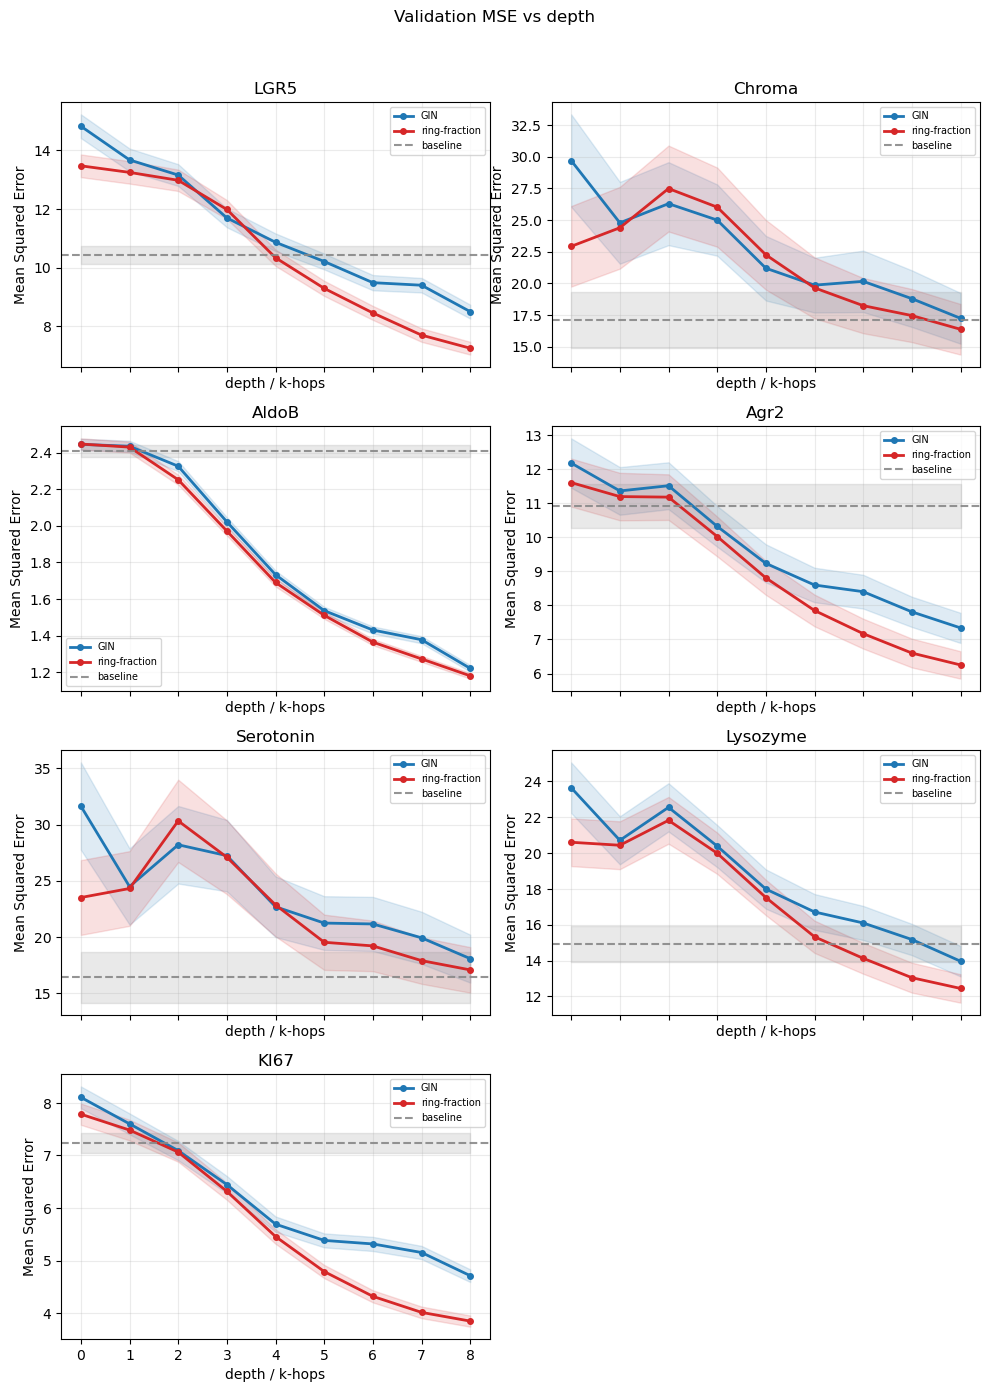

In [41]:
from src.plotting.depth_scan import plot_markerwise_metric_vs_depth, plot_all_aggregates_metric_vs_depth

plt.rcParams.update({
    "axes.spines.top": True,
    "axes.spines.right": True,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

family_colors = {
    "GIN":       "#1f77b4",
    "ring-fraction":      "#d62728",
}


family_order = [
    "GIN",
    "ring-fraction",
]


plot_markerwise_metric_vs_depth(
    all_results=eval_results_residual,
    depths=depths,
    marker_names=marker_names,
    metric_key="mse_model",
    sem_key="sem_mse_model",
    baseline_key="mse_base",
    baseline_sem_key="sem_mse_base",
    ylabel="Mean Squared Error",
    title="Validation MSE vs depth",
    family_order=family_order,
    family_colors=family_colors,
)
plt.show()

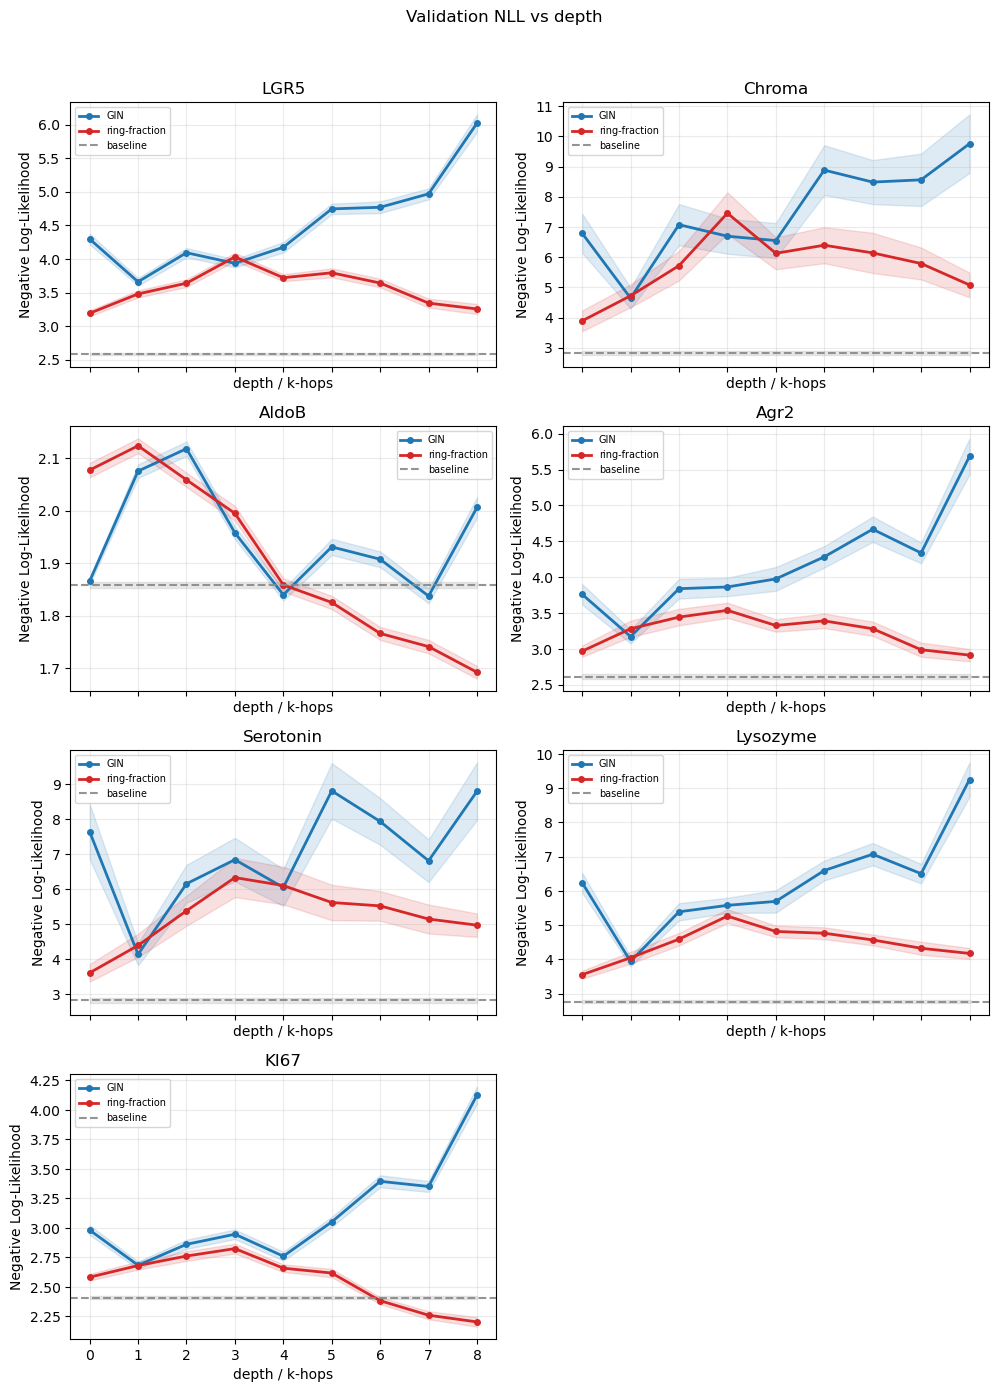

In [42]:
plot_markerwise_metric_vs_depth(
    all_results=eval_results_residual,
    depths=depths,
    marker_names=marker_names,
    metric_key="nll_model",
    sem_key="sem_nll_model",
    baseline_key="nll_base",
    baseline_sem_key="sem_nll_base",
    ylabel="Negative Log-Likelihood",
    title="Validation NLL vs depth",
    family_order=family_order,
    family_colors=family_colors,
)
plt.show()

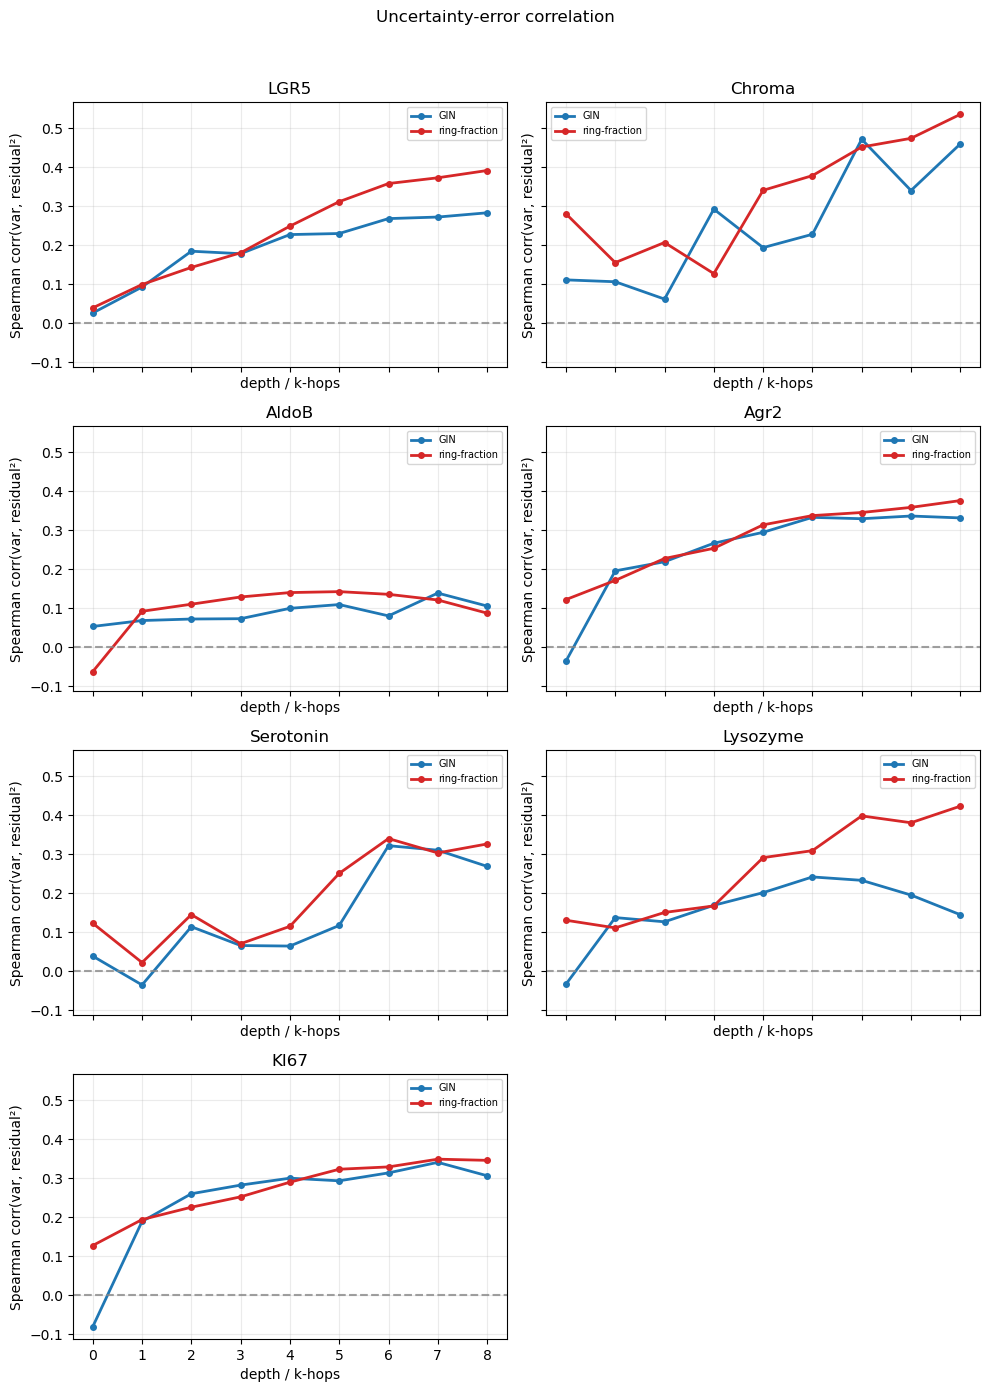

In [43]:

plot_markerwise_metric_vs_depth(
    all_results=eval_results_residual,
    depths=depths,
    marker_names=marker_names,
    metric_key="rho_marker",
    baseline_hline=0.0,
    ylabel="Spearman corr(var, residual²)",
    title="Uncertainty-error correlation",
    family_order=family_order,
    family_colors=family_colors,
    sharey=True,
)
plt.show()